<a href="https://colab.research.google.com/github/yaseenmlm/Machine-Learning-Projects/blob/main/Company_Sentiment_BERTopic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏢 Company Tweet Sentiment + Topic Analyzer
**BERTopic for topic discovery · Zero-shot sentiment per topic cluster**

Dataset: [Twitter Entity Sentiment Analysis](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis)

---
### Pipeline
1. Load & filter dataset to **one company**
2. Clean tweets
3. Embed with `sentence-transformers` (all-MiniLM-L6-v2)
4. **BERTopic** — discover tweet topics
5. **Sentiment** — use existing labels (or zero-shot fallback)
6. Cross-tabulate topics × sentiment
7. Dashboard visualizations

In [ ]:
# Cell 1 — Install dependencies
# BERTopic pulls in sentence-transformers, umap-learn, hdbscan automatically
!pip install bertopic sentence-transformers transformers torch \
             scikit-learn matplotlib seaborn plotly --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.9 MB/s eta 0:00:00


In [ ]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import torch
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [ ]:
# Cell 3 — Load dataset
# Download from: https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis
# Upload twitter_training.csv + twitter_validation.csv, or use Kaggle API:
#   !kaggle datasets download -d jp797498e/twitter-entity-sentiment-analysis
#   !unzip twitter-entity-sentiment-analysis.zip

from google.colab import drive

# mount your google drive
drive.mount('/content/drive')

col_names = ['id', 'company', 'sentiment', 'tweet']
train_df = pd.read_csv('/content/drive/MyDrive/Kaggle_Tweets_Database/twitter_training.csv',   header=None, names=col_names)
val_df   = pd.read_csv('/content/drive/MyDrive/Kaggle_Tweets_Database/twitter_validation.csv', header=None, names=col_names)

# Combine for more data (BERTopic benefits from larger corpora)
full_df = pd.concat([train_df, val_df], ignore_index=True)

print('Total rows:', len(full_df))
print('\nAvailable companies:')
print(sorted(full_df['company'].unique()))

Mounted at /content/drive
Total rows: 75682

Available companies:
['Amazon', 'ApexLegends', 'AssassinsCreed', 'Battlefield', 'Borderlands', 'CS-GO', 'CallOfDuty', 'CallOfDutyBlackopsColdWar', 'Cyberpunk2077', 'Dota2', 'FIFA', 'Facebook', 'Fortnite', 'Google', 'GrandTheftAuto(GTA)', 'Hearthstone', 'HomeDepot', 'LeagueOfLegends', 'MaddenNFL', 'Microsoft', 'NBA2K', 'Nvidia', 'Overwatch', 'PlayStation5(PS5)', 'PlayerUnknownsBattlegrounds(PUBG)', 'RedDeadRedemption(RDR)', 'TomClancysGhostRecon', 'TomClancysRainbowSix', 'Verizon', 'WorldOfCraft', 'Xbox(Xseries)', 'johnson&johnson']


In [ ]:
# Cell 4 — Choose company & filter
# ============================================================
TARGET_COMPANY = 'Amazon'   # <-- Change to any company from the list above
# ============================================================

def filter_company(df, company):
    df = df[df['company'].str.lower() == company.lower()].copy()
    df = df[df['sentiment'] != 'Irrelevant']
    df = df.dropna(subset=['tweet', 'sentiment'])
    df['tweet'] = df['tweet'].astype(str)
    return df.reset_index(drop=True)

company_df = filter_company(full_df, TARGET_COMPANY)

print(f'Company        : {TARGET_COMPANY}')
print(f'Tweets         : {len(company_df)}')
print('\nSentiment breakdown:')
print(company_df['sentiment'].value_counts())

Company        : Amazon
Tweets         : 2121

Sentiment breakdown:
sentiment
Neutral     1225
Negative     581
Positive     315
Name: count, dtype: int64


In [ ]:
# Cell 5 — Tweet cleaning
def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '@user', text)            # anonymize mentions
    text = re.sub(r'#(\w+)', r'\1', text)            # strip # symbol
    text = re.sub(r'&amp;', '&', text)               # HTML entities
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)      # remove non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()
    return text

company_df['tweet_clean'] = company_df['tweet'].apply(clean_tweet)

# Drop tweets that are too short after cleaning (less informative for topics)
company_df = company_df[company_df['tweet_clean'].str.len() > 20].reset_index(drop=True)

tweets = company_df['tweet_clean'].tolist()
print(f'Clean tweets ready: {len(tweets)}')
print('\nSamples:')
for t in tweets[:3]:
    print(f'  {t[:120]}')

Clean tweets ready: 2004

Samples:
  I m really disappointed with amazon today! I ordered a kindle from lightning deal, but then the order was canceled due t
  I am really disappointed with Amazon today! I ordered a lightning deal, but then the order was cancelled due to payment 
  I'm really disappointed with amazon today! I ordered a Kindle from lighting deal, but then the order was cancelled due t


In [ ]:
# Cell 6 — Sentence embeddings
# all-MiniLM-L6-v2 is fast, small, and works great for short texts
print('Loading sentence transformer...')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

print('Encoding tweets (this may take a minute)...')
embeddings = embedding_model.encode(
    tweets,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f'Embedding shape: {embeddings.shape}')  # (n_tweets, 384)

Loading sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding tweets (this may take a minute)...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (2004, 384)


In [ ]:
# Cell 7 — Configure & run BERTopic

# UMAP: reduce 384-dim embeddings to lower dim for clustering
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# HDBSCAN: density-based clustering (handles noise as topic -1)
hdbscan_model = HDBSCAN(
    min_cluster_size=10,       # min tweets per topic — lower for small datasets
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# CountVectorizer: controls what words appear in topic labels
vectorizer_model = CountVectorizer(
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2)         # unigrams + bigrams for richer labels
)

# KeyBERT-inspired representation for more meaningful topic keywords
representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    nr_topics='auto',          # let BERTopic decide how many topics
    top_n_words=10,
    verbose=True
)

print('Fitting BERTopic...')
topics, probs = topic_model.fit_transform(tweets, embeddings)

company_df['topic_id'] = topics
company_df['topic_prob'] = probs if probs is not None and len(np.array(probs).shape) == 1 \
                           else [max(p) if hasattr(p, '__len__') else p for p in (probs or [0]*len(topics))]

print(f'\nTopics found (excl. outlier -1): {len(set(topics)) - (1 if -1 in topics else 0)}')
print(f'Outlier tweets (topic -1)      : {topics.count(-1)}')

2026-09-12 17:44:51,410 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic...


2026-09-12 17:45:27,838 - BERTopic - Dimensionality - Completed ✓
2026-09-12 17:45:27,840 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-12 17:45:27,912 - BERTopic - Cluster - Completed ✓
2026-09-12 17:45:27,913 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-12 17:45:28,016 - BERTopic - Representation - Completed ✓
2026-09-12 17:45:28,017 - BERTopic - Topic reduction - Reducing number of topics
2026-09-12 17:45:28,035 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-12 17:45:29,476 - BERTopic - Representation - Completed ✓
2026-09-12 17:45:29,479 - BERTopic - Topic reduction - Reduced number of topics from 79 to 59



Topics found (excl. outlier -1): 58
Outlier tweets (topic -1)      : 299


In [ ]:
# Cell 8 — Inspect topic info
topic_info = topic_model.get_topic_info()
print(topic_info[['Topic', 'Count', 'Name']].to_string(index=False))

 Topic  Count                                                          Name
    -1    299                  -1_amazon bestseller_sellers_bestseller_sale
     0    402          0_buy amazon_online amazon_amazon amazon_love amazon
     1    201                                       1_card_global_cards_win
     2    135            2_quiz amazon_exciting rewards_game amazon_rewards
     3     55                          3_podcast_pandora_amazon alexa_alexa
     4     44           4_amazon review_amazon bestseller_reviews_paperback
     5     41              5_delivery_shipping_amazon prime_amazon packages
     6     30                                      6_shirt_fashion_wear_fit
     7     30                     7_microsoft_software_amazon_amazon amazon
     8     28                                          8_buff ly_buff_ly_28
     9     25  9_amazon kindle_amazon sale_amazon today_disappointed amazon
    10     23               10_pandemic_amazon workers_employees_protection
    11     2

In [ ]:
# Cell 9 — (Optional) Rename topics with readable labels
# BERTopic auto-generates names like "0_iphone_battery_screen"
# You can override them here after inspecting Cell 8 output.
# Example:
#   topic_model.set_topic_labels({0: 'iPhone Hardware', 1: 'App Store', 2: 'Privacy'})
#
# For now we use the auto-generated names.

# Build a topic_id -> readable name mapping
topic_names = {
    row['Topic']: row['Name']
    for _, row in topic_info.iterrows()
}
topic_names[-1] = 'Outliers'

company_df['topic_name'] = company_df['topic_id'].map(topic_names)
print('Topic name column added.')

Topic name column added.


In [ ]:
# Cell 10 — Sentiment × Topic cross-tabulation
# The dataset already has gold-label sentiment — we use that directly.
# If you want to run zero-shot instead, see the optional Cell 11.

# Exclude outlier topic for cleaner analysis
analysis_df = company_df[company_df['topic_id'] != -1].copy()

# Cross-tab: rows = topics, cols = sentiment
crosstab = pd.crosstab(
    analysis_df['topic_name'],
    analysis_df['sentiment'],
    normalize='index'          # row-normalize → proportions per topic
).round(3)

# Ensure all three sentiment columns exist
for col in ['Negative', 'Neutral', 'Positive']:
    if col not in crosstab.columns:
        crosstab[col] = 0.0

crosstab = crosstab[['Negative', 'Neutral', 'Positive']]

print('Sentiment proportions per topic (rows sum to 1.0):')
print(crosstab.to_string())

Sentiment proportions per topic (rows sum to 1.0):
sentiment                                                      Negative  Neutral  Positive
topic_name                                                                                
0_buy amazon_online amazon_amazon amazon_love amazon              0.403    0.463     0.134
10_pandemic_amazon workers_employees_protection                   0.522    0.217     0.261
11_wish list_amazon wish_items amazon_julie                       0.000    1.000     0.000
12_health_100 million_care_people                                 0.545    0.409     0.045
13_pre_romance_sister_black                                       0.000    1.000     0.000
14_screen_amazon best_best amazon_amazon review                   0.000    0.632     0.368
15_book ebook_paperback_novel book_ebook                          0.000    1.000     0.000
16_amazon story_amazon reviewer_recommend amazon_love amazon      0.000    0.684     0.316
17_wall_room_gift_birthday             

In [ ]:
# Cell 11 — (Optional) Zero-shot sentiment if you DON'T have labels
# Uncomment if you want to classify your own tweets without gold labels.

# from transformers import pipeline
# print('Loading zero-shot classifier...')
# zsc = pipeline('zero-shot-classification',
#                model='facebook/bart-large-mnli',
#                device=0 if device=='cuda' else -1)
#
# candidate_labels = ['positive', 'negative', 'neutral']
#
# def get_zsc_sentiment(text):
#     result = zsc(text[:512], candidate_labels)
#     return result['labels'][0].capitalize()
#
# print('Running zero-shot sentiment (slow without GPU)...')
# company_df['sentiment_zsc'] = company_df['tweet_clean'].apply(get_zsc_sentiment)
# print(company_df['sentiment_zsc'].value_counts())

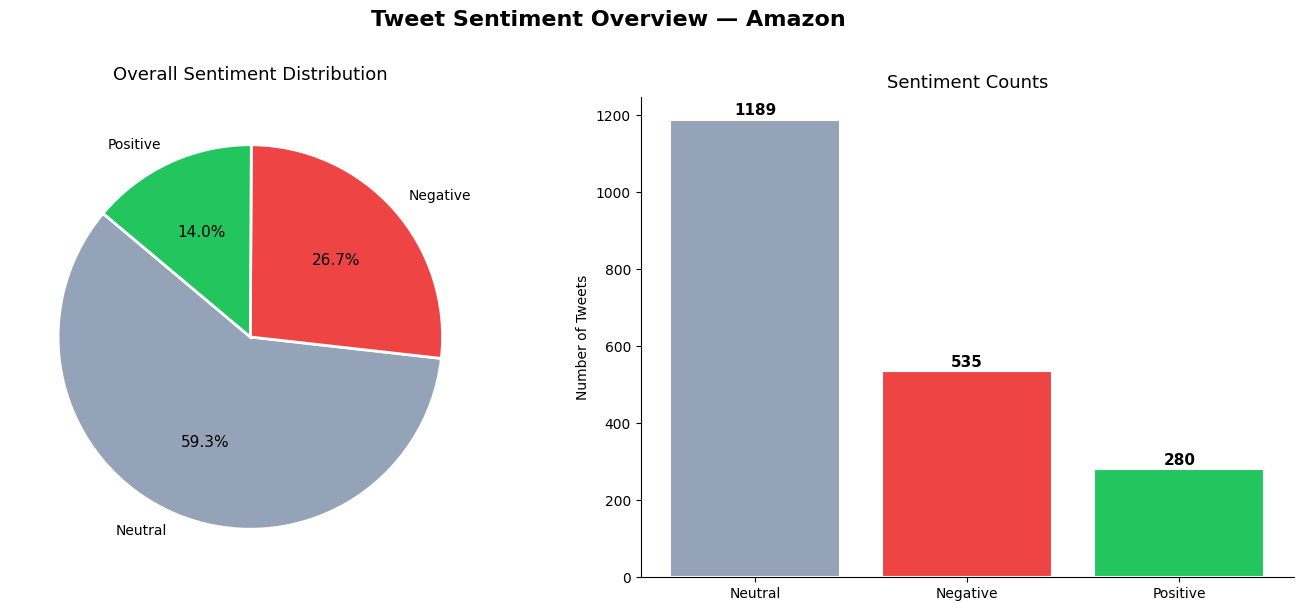

Saved: fig1_overall_sentiment.png


In [ ]:
# Cell 12 — Dashboard: Figure 1 — Overall sentiment pie
sentiment_counts = company_df['sentiment'].value_counts()

COLORS = {
    'Positive': '#22c55e',
    'Neutral':  '#94a3b8',
    'Negative': '#ef4444'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Tweet Sentiment Overview — {TARGET_COMPANY}',
             fontsize=16, fontweight='bold', y=1.01)

# Pie
ax = axes[0]
labels = sentiment_counts.index.tolist()
sizes  = sentiment_counts.values.tolist()
colors = [COLORS.get(l, '#888') for l in labels]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title('Overall Sentiment Distribution', fontsize=13, pad=12)

# Bar count
ax2 = axes[1]
bars = ax2.bar(labels, sizes,
               color=[COLORS.get(l, '#888') for l in labels],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sizes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Tweets')
ax2.set_title('Sentiment Counts', fontsize=13)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_overall_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_overall_sentiment.png')

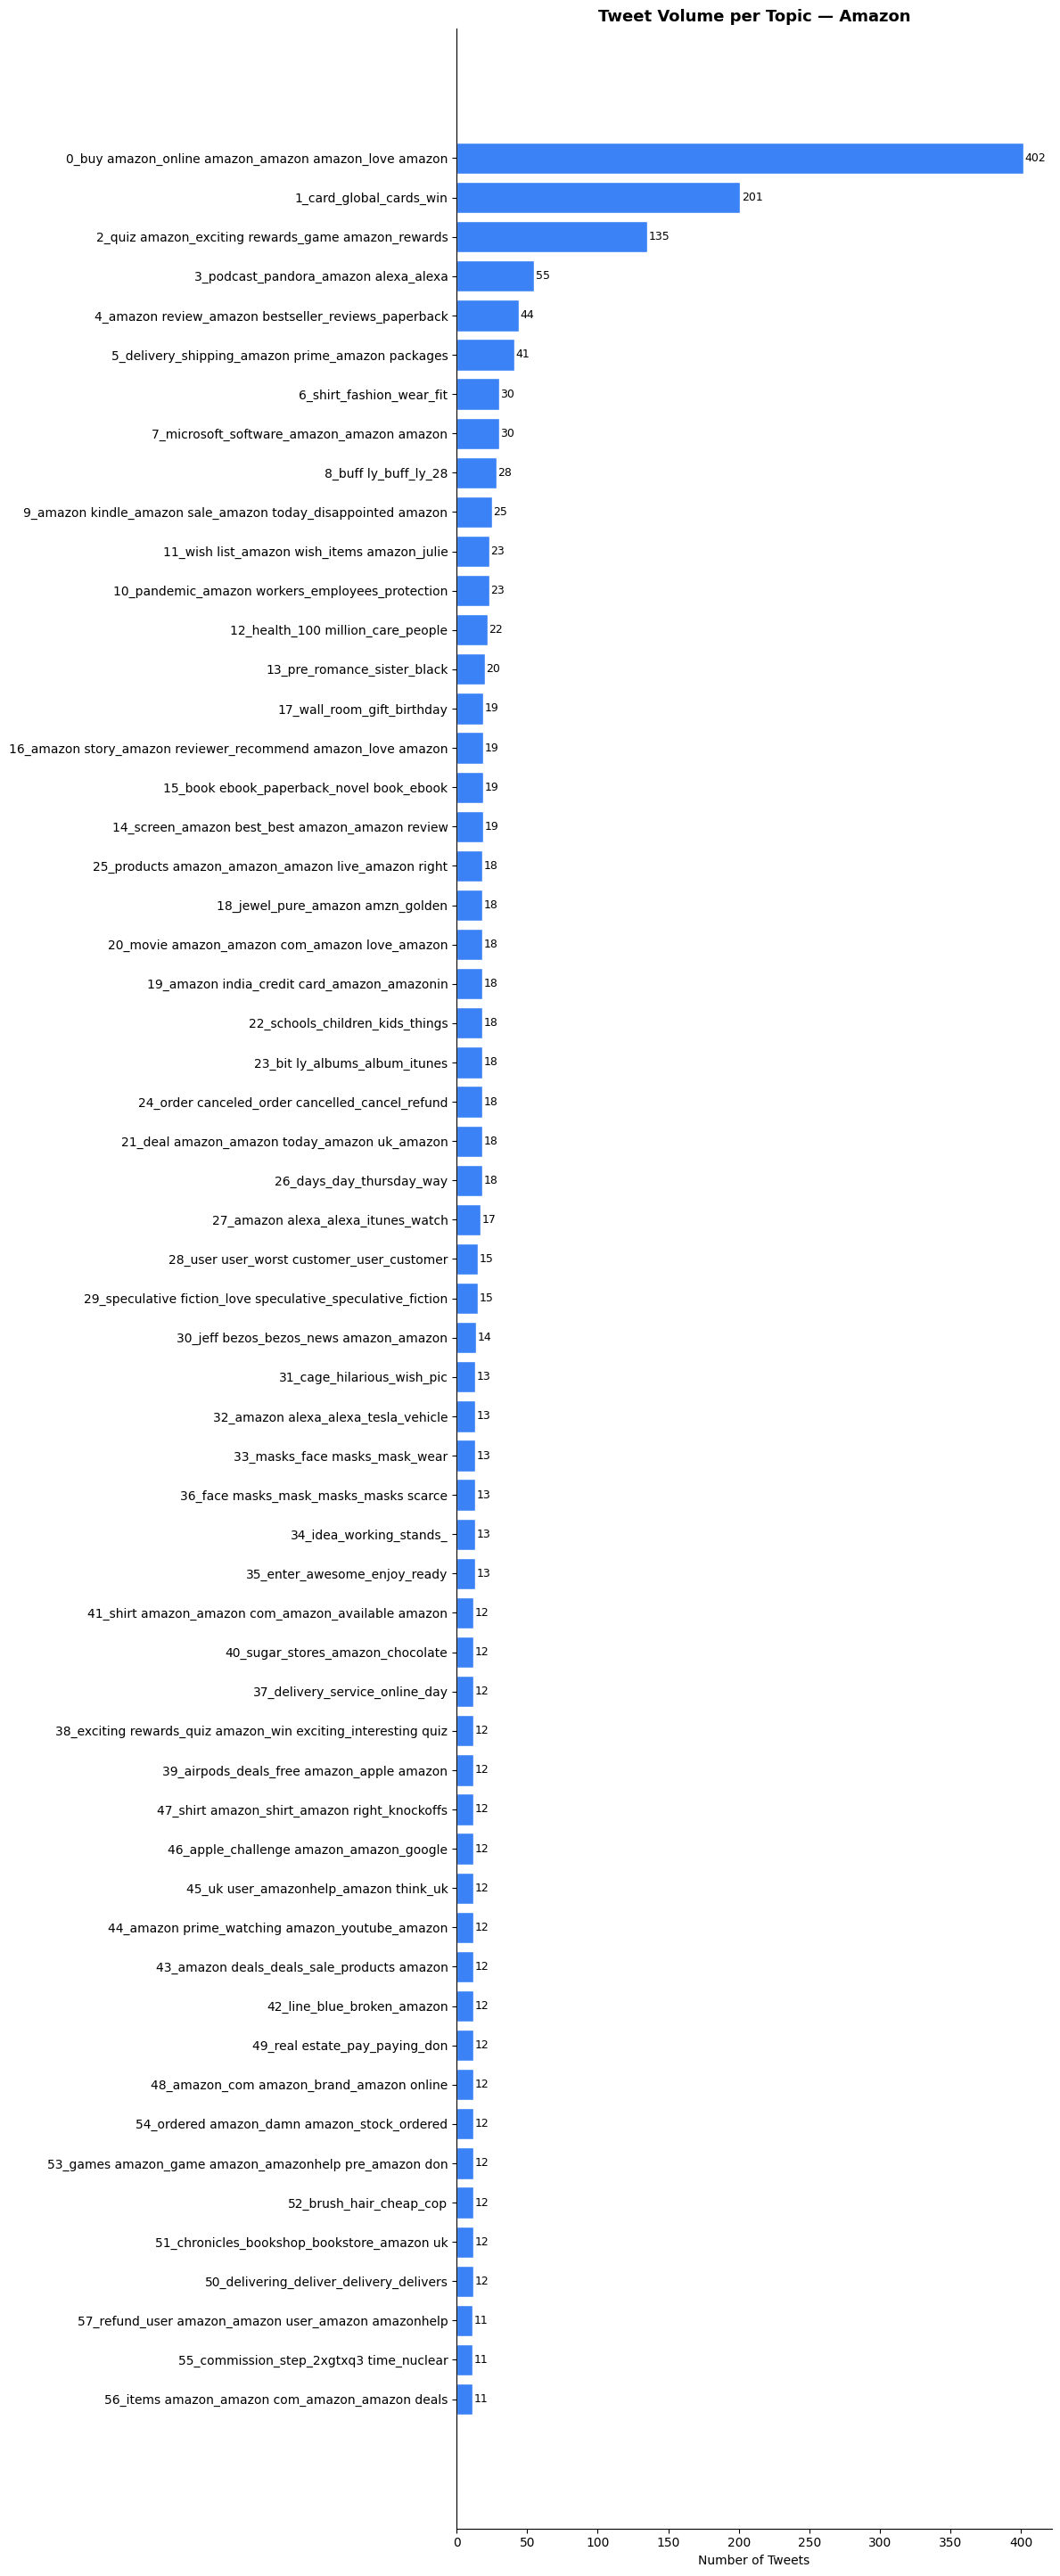

Saved: fig2_topic_volumes.png


In [ ]:
# Cell 13 — Dashboard: Figure 2 — Topic size bar chart
topic_counts = (
    analysis_df.groupby('topic_name')
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, max(4, len(topic_counts) * 0.5)))
bars = ax.barh(topic_counts.index[::-1], topic_counts.values[::-1],
               color='#3b82f6', edgecolor='white')
for bar, val in zip(bars, topic_counts.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Number of Tweets')
ax.set_title(f'Tweet Volume per Topic — {TARGET_COMPANY}', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_topic_volumes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_topic_volumes.png')

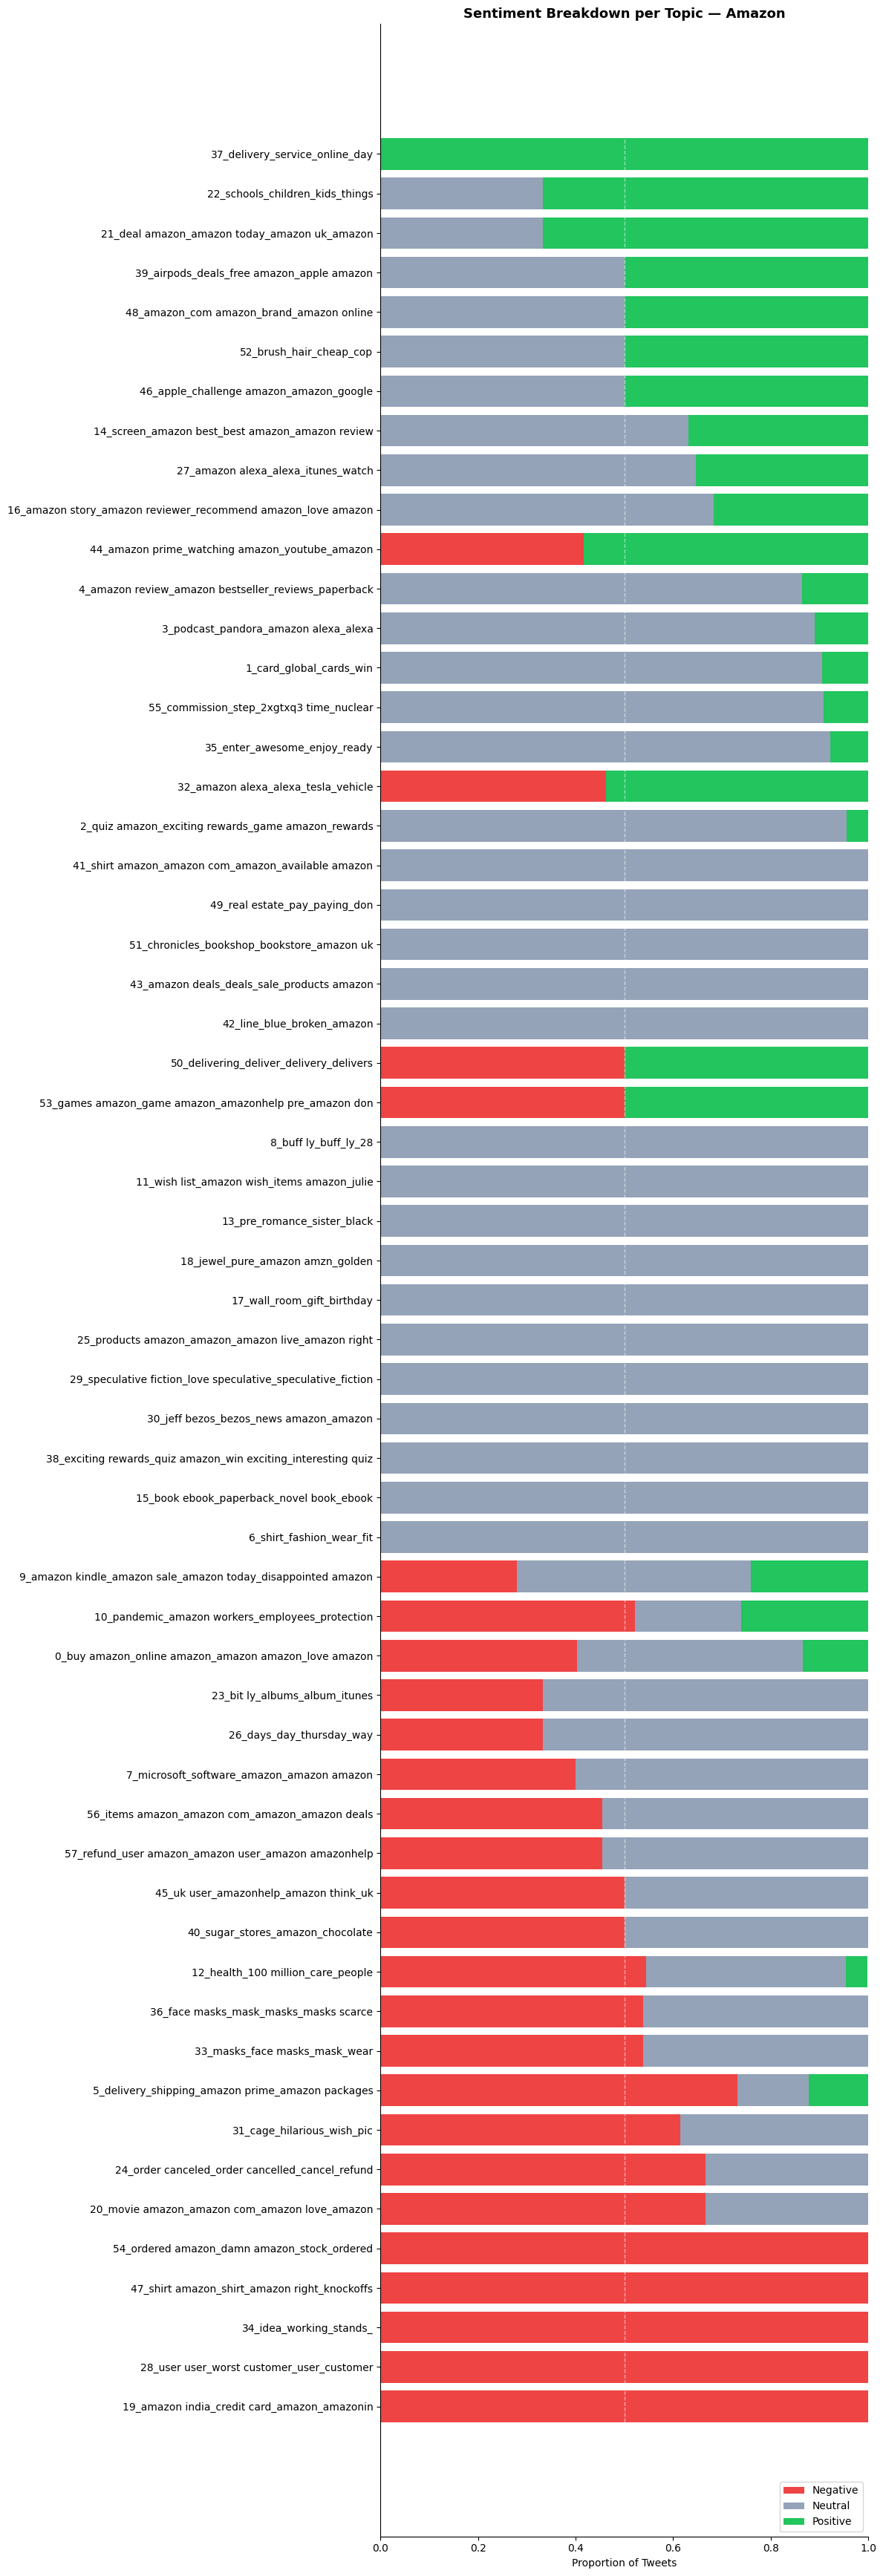

Saved: fig3_sentiment_per_topic.png


In [ ]:
# Cell 14 — Dashboard: Figure 3 — Stacked bar: sentiment per topic
plot_data = crosstab.copy()

# Sort by positivity score (most positive topics on top)
plot_data['pos_score'] = plot_data['Positive'] - plot_data['Negative']
plot_data = plot_data.sort_values('pos_score', ascending=True).drop(columns='pos_score')

fig, ax = plt.subplots(figsize=(12, max(5, len(plot_data) * 0.6)))

left_neg = np.zeros(len(plot_data))
left_neu = plot_data['Negative'].values
left_pos = plot_data['Negative'].values + plot_data['Neutral'].values

ax.barh(plot_data.index, plot_data['Negative'], color='#ef4444', label='Negative')
ax.barh(plot_data.index, plot_data['Neutral'],  left=left_neu, color='#94a3b8', label='Neutral')
ax.barh(plot_data.index, plot_data['Positive'], left=left_pos, color='#22c55e', label='Positive')

ax.set_xlabel('Proportion of Tweets')
ax.set_title(f'Sentiment Breakdown per Topic — {TARGET_COMPANY}',
             fontsize=13, fontweight='bold')
ax.axvline(0.5, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_sentiment_per_topic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_sentiment_per_topic.png')

Running 2D UMAP for visualization...


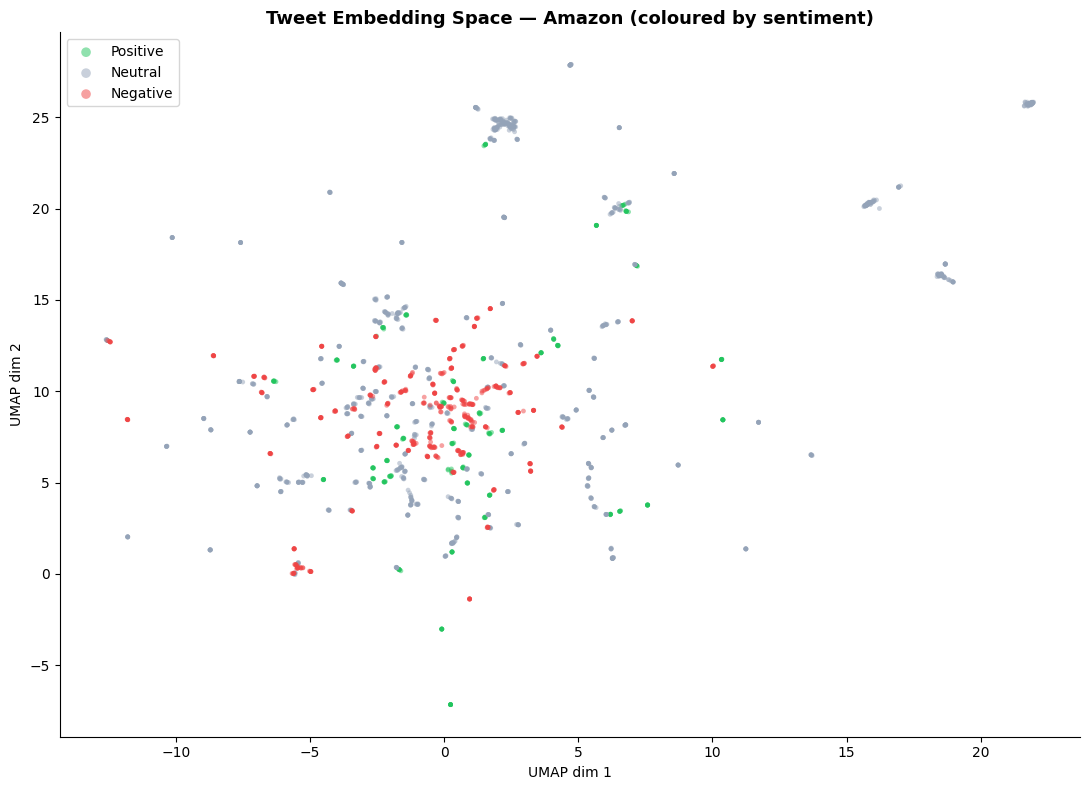

Saved: fig4_umap_scatter.png


In [ ]:
# Cell 15 — Dashboard: Figure 4 — UMAP 2D scatter coloured by sentiment
# Re-run UMAP to 2D just for visualization (separate from the 5D used in clustering)
from umap import UMAP as UMAP2D

print('Running 2D UMAP for visualization...')
umap_2d = UMAP2D(n_components=2, metric='cosine', random_state=42, n_neighbors=15)
emb_2d  = umap_2d.fit_transform(embeddings)

company_df['umap_x'] = emb_2d[:, 0]
company_df['umap_y'] = emb_2d[:, 1]

fig, ax = plt.subplots(figsize=(11, 8))
for sentiment, color in COLORS.items():
    mask = company_df['sentiment'] == sentiment
    ax.scatter(
        company_df.loc[mask, 'umap_x'],
        company_df.loc[mask, 'umap_y'],
        c=color, label=sentiment, alpha=0.5, s=12, edgecolors='none'
    )

ax.legend(markerscale=2, framealpha=0.8)
ax.set_title(f'Tweet Embedding Space — {TARGET_COMPANY} (coloured by sentiment)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_umap_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_umap_scatter.png')

In [ ]:
# Cell 16 — Dashboard: Figure 5 — BERTopic built-in visualizations (interactive HTML)
# These open as interactive Plotly charts inside Colab

# Topic word scores
topic_model.visualize_barchart(top_n_topics=min(10, len(set(topics))-1))

In [ ]:
# Cell 17 — BERTopic: intertopic distance map
topic_model.visualize_topics()

In [ ]:
# Cell 18 — BERTopic: document map (2D UMAP coloured by topic)
topic_model.visualize_documents(
    tweets,
    embeddings=embeddings,
    hide_annotations=True   # cleaner for large datasets
)

In [ ]:
# Cell 19 — Sample tweets per topic
print(f'=== Sample tweets per topic for {TARGET_COMPANY} ===\n')
for topic_id in sorted(analysis_df['topic_id'].unique()):
    subset = analysis_df[analysis_df['topic_id'] == topic_id]
    name   = topic_names.get(topic_id, str(topic_id))
    print(f'Topic {topic_id}: {name}  ({len(subset)} tweets)')
    sent_dist = subset['sentiment'].value_counts().to_dict()
    print(f'  Sentiment: {sent_dist}')
    samples = subset.sample(min(3, len(subset)), random_state=42)
    for _, row in samples.iterrows():
        print(f'  [{row["sentiment"]:8s}] {row["tweet_clean"][:110]}')
    print()

=== Sample tweets per topic for Amazon ===

Topic 0: 0_buy amazon_online amazon_amazon amazon_love amazon  (402 tweets)
  Sentiment: {'Neutral': 186, 'Negative': 162, 'Positive': 54}
  [Negative] Definitely walmart. Amazon gonna fuck you over with the shipping .
  [Neutral ] Turmoil in Turmoil in Turkey by Jon Grainge amazon.com / dp / 1366525523 /... via @ amazon / / Fenco / UCQA3PP
  [Positive] Quarantine caused me to order 9 Amazon parcels in a week

Topic 1: 1_card_global_cards_win  (201 tweets)
  Sentiment: {'Neutral': 182, 'Positive': 19}
  [Positive] Congratulations were our $50 Amazon gift card winners: @user R @user!!! We will be sending our members the gif
  [Neutral ] @user Thanks for joining Grand Summoners .. See the video to reveal if you won your $100 Amazon gift card!. Re
  [Neutral ] Win a $25 Amazon Gift Card in the Fantastic Father Giveaway Hop

Topic 2: 2_quiz amazon_exciting rewards_game amazon_rewards  (135 tweets)
  Sentiment: {'Neutral': 129, 'Positive': 6}
  [N

In [ ]:
# Cell 20 — Summary table: most positive and most negative topics
summary = crosstab.copy()
summary['tweet_count'] = analysis_df.groupby('topic_name').size()
summary['net_sentiment'] = summary['Positive'] - summary['Negative']
summary = summary.sort_values('net_sentiment', ascending=False)

print(f'\nSentiment Summary — {TARGET_COMPANY}')
print('='*70)
print(summary[['tweet_count','Positive','Neutral','Negative','net_sentiment']]
      .rename(columns={'net_sentiment': 'net (pos-neg)'})
      .to_string())
print('\n(net > 0 = more positive, net < 0 = more negative)')


Sentiment Summary — Amazon
sentiment                                                      tweet_count  Positive  Neutral  Negative  net (pos-neg)
topic_name                                                                                                            
37_delivery_service_online_day                                          12     1.000    0.000     0.000          1.000
22_schools_children_kids_things                                         18     0.667    0.333     0.000          0.667
21_deal amazon_amazon today_amazon uk_amazon                            18     0.667    0.333     0.000          0.667
48_amazon_com amazon_brand_amazon online                                12     0.500    0.500     0.000          0.500
39_airpods_deals_free amazon_apple amazon                               12     0.500    0.500     0.000          0.500
46_apple_challenge amazon_amazon_google                                 12     0.500    0.500     0.000          0.500
52_brush_hair_cheap_

In [ ]:
# Cell 21 — (Optional) Predict sentiment on NEW tweets using BERTopic topics
# Given a list of new tweets about the company, assign them a topic and
# report the expected sentiment distribution for that topic.

new_tweets = [
    'The new iPhone battery life is incredible, lasts all day easily!',
    'Apple keeps raising prices, this is getting ridiculous',
    'Just updated to the latest iOS, running smoothly so far',
]

new_tweets_clean = [clean_tweet(t) for t in new_tweets]
new_topics, new_probs = topic_model.transform(new_tweets_clean)

print('New tweet topic assignments:\n')
for tweet, topic_id in zip(new_tweets, new_topics):
    name = topic_names.get(topic_id, f'Topic {topic_id}')
    if topic_id != -1 and name in crosstab.index:
        dist = crosstab.loc[name]
        predicted = dist.idxmax()
        print(f'Tweet   : {tweet}')
        print(f'Topic   : {name}')
        print(f'Expected sentiment distribution: '
              f'Pos={dist["Positive"]:.0%} Neu={dist["Neutral"]:.0%} Neg={dist["Negative"]:.0%}')
        print(f'Most likely sentiment: {predicted}\n')
    else:
        print(f'Tweet   : {tweet}')
        print(f'Topic   : Outlier (no topic assigned)\n')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-12 17:47:44,412 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-09-12 17:47:46,955 - BERTopic - Dimensionality - Completed ✓
2026-09-12 17:47:46,956 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-09-12 17:47:46,958 - BERTopic - Cluster - Completed ✓


New tweet topic assignments:

Tweet   : The new iPhone battery life is incredible, lasts all day easily!
Topic   : 0_buy amazon_online amazon_amazon amazon_love amazon
Expected sentiment distribution: Pos=13% Neu=46% Neg=40%
Most likely sentiment: Neutral

Tweet   : Apple keeps raising prices, this is getting ridiculous
Topic   : 0_buy amazon_online amazon_amazon amazon_love amazon
Expected sentiment distribution: Pos=13% Neu=46% Neg=40%
Most likely sentiment: Neutral

Tweet   : Just updated to the latest iOS, running smoothly so far
Topic   : 19_amazon india_credit card_amazon_amazonin
Expected sentiment distribution: Pos=0% Neu=0% Neg=100%
Most likely sentiment: Negative

